#day7 2-3-2026
##regression for prediction using k fold spliting

In [1]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).

# /using kflod/
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
import numpy as np

# Step 1: Create synthetic dataset
X, y = make_regression(n_samples=1000,
                       n_features=5,
                       noise=15,
                       random_state=42)

# Step 2: Define Ridge model
model = Ridge(alpha=1.0)

# Step 3: Define 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate model using R^2
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Step 5: Print results
print("R^2 scores for each fold:", scores.round(3))
print("Mean R^2:", scores.mean().round(3))
print("Std dev:", scores.std().round(3))

# Step 6: Interpret the data
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds, investigate further.")

R^2 scores for each fold: [0.937 0.945 0.945 0.947 0.947]
Mean R^2: 0.944
Std dev: 0.004
Model is stable across folds.


In [2]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# Step 1: Create synthetic dataset
# 1000 patients, 5 features, moderate noise
X, y = make_regression(n_samples=1000,
                       n_features=5,
                       noise=20,
                       random_state=42)

# Step 2: Define Linear Regression model
model = LinearRegression()

# Step 3: Define 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate model using R²
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Step 5: Print results
print("R² scores for each fold:", scores.round(3))
print("Mean R²:", scores.mean().round(3))
print("Standard Deviation:", scores.std().round(3))

# Step 6: Interpretation
if scores.std() < 0.05:
    print("Model performance is stable across folds.")
else:
    print("Model performance varies across folds.")

R² scores for each fold: [0.894 0.905 0.906 0.908 0.909]
Mean R²: 0.904
Standard Deviation: 0.005
Model performance is stable across folds.


In [3]:
# Scenario: Predicting Student Exam Performance
# A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
# - Number of study hours per week
# - Attendance percentage in lectures
# - Prior GPA (Grade Point Average)
# - Participation in group projects (numeric engagement score)
# - Average sleep hours during exam preparation
# They collect data from 800 students across different departments and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.
#  Linear Regression
#  800 students
#  5-Fold Cross-Validation
#  R² as evaluation metric

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# Step 1: Create synthetic dataset
# 800 students, 5 features, moderate noise
X, y = make_regression(n_samples=800,
                       n_features=5,
                       noise=18,
                       random_state=42)

# Step 2: Define Linear Regression model
model = LinearRegression()

# Step 3: Define 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate using R²
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Step 5: Print results
print("R² scores for each fold:", scores.round(3))
print("Mean R²:", scores.mean().round(3))
print("Standard Deviation:", scores.std().round(3))

# Step 6: Interpretation
if scores.std() < 0.05:
    print("Model performance is stable across folds.")
else:
    print("Model performance varies across folds.")

R² scores for each fold: [0.981 0.982 0.984 0.983 0.983]
Mean R²: 0.983
Standard Deviation: 0.001
Model performance is stable across folds.


###bias and variences
cross validation

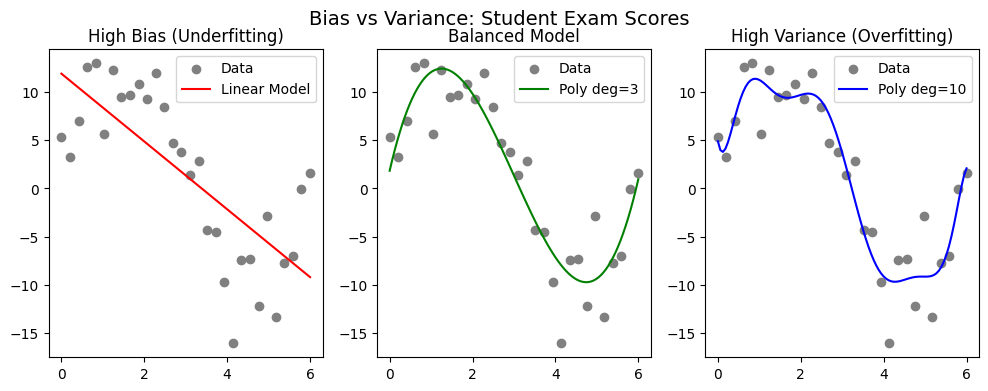

In [4]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()


LINEAR MODEL (High Bias)
Train R²: 0.489
Test R² : 0.19

BALANCED MODEL (Degree 3)
Train R²: 0.646
Test R² : 0.355

POLYNOMIAL MODEL (Degree 10 - High Variance)
Train R²: 0.83
Test R² : -6.332


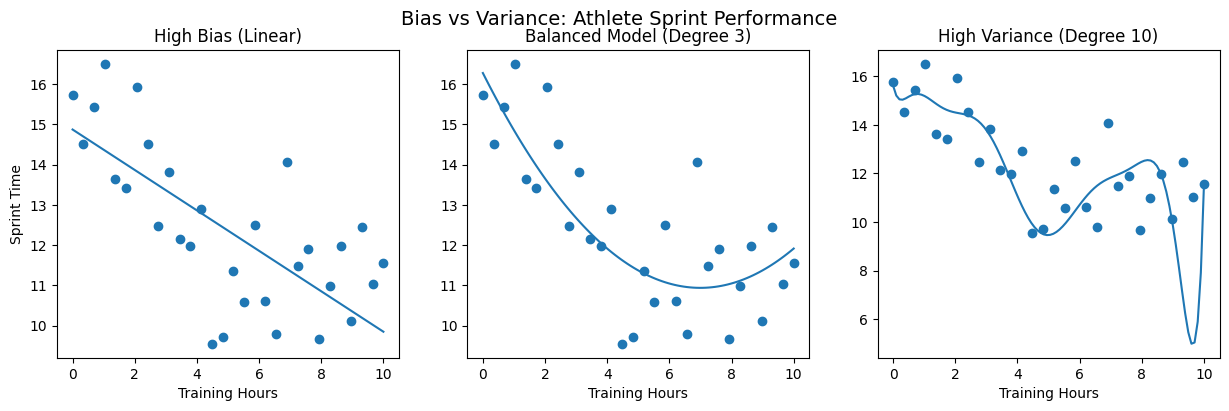

In [5]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Step 1: Simulate Dataset
np.random.seed(42)

# Training hours (0–10 hours)
X = np.linspace(0, 10, 30).reshape(-1, 1)

# True non-linear relationship (sprint improves but not perfectly linear)
true_performance = 15 - 0.8 * X + 0.05 * X**2
noise = np.random.normal(0, 1.5, size=30).reshape(-1, 1)
y = (true_performance + noise).ravel()

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: Define Models
linear_model = make_pipeline(
    PolynomialFeatures(1),
    LinearRegression()
)
balanced_model = make_pipeline(
    PolynomialFeatures(3),
    LinearRegression()
)
poly_model = make_pipeline(
    PolynomialFeatures(10),
    LinearRegression()
)

# Step 3: Train Models
linear_model.fit(X_train, y_train)
balanced_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)

# Step 4: Evaluate Models
def evaluate(model, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Train R²:", round(r2_score(y_train, train_pred), 3))
    print("Test R² :", round(r2_score(y_test, test_pred), 3))
evaluate(linear_model, "LINEAR MODEL (High Bias)")
evaluate(balanced_model, "BALANCED MODEL (Degree 3)")
evaluate(poly_model, "POLYNOMIAL MODEL (Degree 10 - High Variance)")

# Step 5: Visualization
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
plt.figure(figsize=(15, 4))

# Linear
plt.subplot(1, 3, 1)
plt.scatter(X, y)
plt.plot(X_plot, linear_model.predict(X_plot))
plt.title("High Bias (Linear)")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time")

# Balanced
plt.subplot(1, 3, 2)
plt.scatter(X, y)
plt.plot(X_plot, balanced_model.predict(X_plot))
plt.title("Balanced Model (Degree 3)")
plt.xlabel("Training Hours")

# High Variance
plt.subplot(1, 3, 3)
plt.scatter(X, y)
plt.plot(X_plot, poly_model.predict(X_plot))
plt.title("High Variance (Degree 10)")
plt.xlabel("Training Hours")

plt.suptitle("Bias vs Variance: Athlete Sprint Performance", fontsize=14)
plt.show()

##label encoding

In [6]:
# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2)
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle
# this, and what challenge might arise if the model was already trained?

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Create dataset
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

# Create LabelEncoders
size_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

# Fit and transform
data['Size_encoded'] = size_encoder.fit_transform(data['Size'])
data['Priority_encoded'] = priority_encoder.fit_transform(data['Priority'])

print("Encoded Data:\n")
print(data)

# Show mapping
print("\nSize Mapping:")
for i, label in enumerate(size_encoder.classes_):
    print(f"{label} → {i}")

print("\nPriority Mapping:")
for i, label in enumerate(priority_encoder.classes_):
    print(f"{label} → {i}")

# Decode back to original labels
data['Size_decoded'] = size_encoder.inverse_transform(data['Size_encoded'])
data['Priority_decoded'] = priority_encoder.inverse_transform(data['Priority_encoded'])

print("\nDecoded Data:\n")
print(data)

Encoded Data:

     Size Priority  Size_encoded  Priority_encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0

Size Mapping:
Large → 0
Medium → 1
Small → 2

Priority Mapping:
High → 0
Low → 1
Medium → 2

Decoded Data:

     Size Priority  Size_encoded  Priority_encoded Size_decoded  \
0   Small      Low             2                 1        Small   
1  Medium     High             1                 0       Medium   
2   Large   Medium             0                 2        Large   
3  Medium      Low             1                 1       Medium   
4   Small     High             2                 0        Small   

  Priority_decoded  
0              Low  
1             High  
2           Medium  
3              Low  
4             High  


In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Create Dataset
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})
print("Original Data:\n")
print(data)

# Step 2: Initialize Encoders
size_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

# Step 3: Encode Features
data['Size_encoded'] = size_encoder.fit_transform(data['Size'])
data['Priority_encoded'] = priority_encoder.fit_transform(data['Priority'])
print("\nEncoded Data:\n")
print(data)

# Step 4: Display Mappings
print("\nSize Mapping:")
size_mapping = dict(zip(size_encoder.classes_, size_encoder.transform(size_encoder.classes_)))
print(size_mapping)
print("\nPriority Mapping:")
priority_mapping = dict(zip(priority_encoder.classes_, priority_encoder.transform(priority_encoder.classes_)))
print(priority_mapping)

# Step 5: Decode Back
data['Size_decoded'] = size_encoder.inverse_transform(data['Size_encoded'])
data['Priority_decoded'] = priority_encoder.inverse_transform(data['Priority_encoded'])
print("\nDecoded Data:\n")
print(data)

Original Data:

     Size Priority
0   Small      Low
1  Medium     High
2   Large   Medium
3  Medium      Low
4   Small     High

Encoded Data:

     Size Priority  Size_encoded  Priority_encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0

Size Mapping:
{'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}

Priority Mapping:
{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Decoded Data:

     Size Priority  Size_encoded  Priority_encoded Size_decoded  \
0   Small      Low             2                 1        Small   
1  Medium     High             1                 0       Medium   
2   Large   Medium             0                 2        Large   
3  Medium      Low             1                 1       Medium   
4   Small     High            

In [8]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to
# convert these categories into numbers.
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Create Dataset
data = pd.DataFrame({
    'Meal_Type': ['Breakfast', 'Lunch', 'Dinner', 'Lunch', 'Breakfast'],
    'Spice_Level': ['Mild', 'Hot', 'Medium', 'Mild', 'Hot']
})
print("Original Data:\n")
print(data)

# Step 2: Initialize Encoders
meal_encoder = LabelEncoder()
spice_encoder = LabelEncoder()

# Step 3: Apply Label Encoding
data['Meal_Type_Encoded'] = meal_encoder.fit_transform(data['Meal_Type'])
data['Spice_Level_Encoded'] = spice_encoder.fit_transform(data['Spice_Level'])
print("\nEncoded Data:\n")
print(data)

# Step 4: Show Mappings
print("\nMeal Type Mapping:")
meal_mapping = dict(zip(meal_encoder.classes_,
                        meal_encoder.transform(meal_encoder.classes_)))
print(meal_mapping)
print("\nSpice Level Mapping:")
spice_mapping = dict(zip(spice_encoder.classes_,
                         spice_encoder.transform(spice_encoder.classes_)))
print(spice_mapping)

# Step 5: Decode Back
data['Meal_Type_Decoded'] = meal_encoder.inverse_transform(data['Meal_Type_Encoded'])
data['Spice_Level_Decoded'] = spice_encoder.inverse_transform(data['Spice_Level_Encoded'])
print("\nDecoded Data:\n",data)

Original Data:

   Meal_Type Spice_Level
0  Breakfast        Mild
1      Lunch         Hot
2     Dinner      Medium
3      Lunch        Mild
4  Breakfast         Hot

Encoded Data:

   Meal_Type Spice_Level  Meal_Type_Encoded  Spice_Level_Encoded
0  Breakfast        Mild                  0                    2
1      Lunch         Hot                  2                    0
2     Dinner      Medium                  1                    1
3      Lunch        Mild                  2                    2
4  Breakfast         Hot                  0                    0

Meal Type Mapping:
{'Breakfast': np.int64(0), 'Dinner': np.int64(1), 'Lunch': np.int64(2)}

Spice Level Mapping:
{'Hot': np.int64(0), 'Medium': np.int64(1), 'Mild': np.int64(2)}

Decoded Data:
    Meal_Type Spice_Level  Meal_Type_Encoded  Spice_Level_Encoded  \
0  Breakfast        Mild                  0                    2   
1      Lunch         Hot                  2                    0   
2     Dinner      Medium     

In [9]:

import pandas as pd
# Create the original dataset
data = {
    "Patient ID": ["P001", "P002", "P003"],
    "Blood Type": ["O+", "A+", "B+"],
    "Age": [45, 52, 38],
    "Risk": ["Low", "High", "Medium"]
}
df = pd.DataFrame(data)
# One-hot encode Blood Type column
df_encoded = pd.get_dummies(df, columns=["Blood Type"], prefix="Blood")
print(df_encoded)

  Patient ID  Age    Risk  Blood_A+  Blood_B+  Blood_O+
0       P001   45     Low     False     False      True
1       P002   52    High      True     False     False
2       P003   38  Medium     False      True     False


In [10]:
# One-Hot Encoding using scikit-learn's OneHotEncoder
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# Original dataset
data = {
    "Patient ID": ["P001", "P002", "P003"],
    "Blood Type": ["O+", "A+", "B+"],
    "Age": [45, 52, 38],
    "Risk": ["Low", "High", "Medium"]
}
df = pd.DataFrame(data)
# Initialize encoder
encoder = OneHotEncoder(sparse_output=False)
# Fit and transform Blood Type column
encoded = encoder.fit_transform(df[["Blood Type"]])
# Get new column names
encoded_cols = encoder.get_feature_names_out(["Blood Type"])
# Create encoded DataFrame
encoded_df = pd.DataFrame(encoded, columns=encoded_cols)
# Combine with original dataset (drop Blood Type)
final_df = pd.concat([df.drop("Blood Type", axis=1), encoded_df], axis=1)
print(final_df)

  Patient ID  Age    Risk  Blood Type_A+  Blood Type_B+  Blood Type_O+
0       P001   45     Low            0.0            0.0            1.0
1       P002   52    High            1.0            0.0            0.0
2       P003   38  Medium            0.0            1.0            0.0


In [11]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they
# update their encoding scheme to keep the order meaningful?

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

#Sample dataset
data = {
    "Education": ["High School","Bachelor","Master","PhD","Bachelor"],
    "Satisfaction": ["Poor","Good","Excellent","Average","Good"]
}

df = pd.DataFrame(data)

# Define custom order
education_order = ["High School", "Bachelor", "Master", "PhD"]
satisfaction_order = ["Poor", "Average", "Good", "Excellent"]

# Initialize OrdinalEncoder with custom categories
encoder = OrdinalEncoder(categories=[education_order, satisfaction_order])

# Fit and transform
df_encoded = df.copy()
df_encoded[["Education", "Satisfaction"]] = encoder.fit_transform(
    df[["Education", "Satisfaction"]]
)
print(df_encoded)

   Education  Satisfaction
0        0.0           0.0
1        1.0           2.0
2        2.0           3.0
3        3.0           1.0
4        1.0           2.0


In [12]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

#dataset
data = {
    "Disease Severity": ["Mild","Severe","Critical","Moderate","Severe"],
    "Recovery Satisfaction": ["Good","Poor","Excellent","Average","Good"]
}
df = pd.DataFrame(data)
# Define custom order
severity_order = ["Mild","Moderate","Severe","Critical"]
satisfaction_order = ["Poor","Average","Good","Excellent"]
# Initialize OrdinalEncoder
encoder = OrdinalEncoder(categories=[severity_order,satisfaction_order])
# Apply encoding
df_encoded = df.copy()
df_encoded[["Disease Severity", "Recovery Satisfaction"]] = encoder.fit_transform(
    df[["Disease Severity","Recovery Satisfaction"]]
)
print("Encoded using OrdinalEncoder:\n")
print(df_encoded)

# Manual Dictionary Mapping (Consistency Check)
# Define manual mappings
severity_map = {
    "Mild": 0,
    "Moderate": 1,
    "Severe": 2,
    "Critical": 3
}
satisfaction_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
}
df_manual = df.copy()
df_manual["Disease Severity"] = df_manual["Disease Severity"].map(severity_map)
df_manual["Recovery Satisfaction"] = df_manual["Recovery Satisfaction"].map(satisfaction_map)
print("\nEncoded using Manual Mapping:\n")
print(df_manual)

Encoded using OrdinalEncoder:

   Disease Severity  Recovery Satisfaction
0               0.0                    2.0
1               2.0                    0.0
2               3.0                    3.0
3               1.0                    1.0
4               2.0                    2.0

Encoded using Manual Mapping:

   Disease Severity  Recovery Satisfaction
0                 0                      2
1                 2                      0
2                 3                      3
3                 1                      1
4                 2                      2


In [13]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

# Step 1: Sample cuisine data
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
orders = pd.DataFrame({
    'Cuisine': ['Italian', 'Chinese', 'Indian',
                'Mexican', 'Chinese', 'Italian']
})

# Step 2: Apply OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(orders[['Cuisine']])

# Step 3: Convert encoded array back into a DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.categories_[0]
)

# Step 4: Combine with original data
final_data = pd.concat([orders, encoded_df], axis=1)

# Step 5: Display results
print("Cuisine Categories:", encoder.categories_)
print("\nEncoded Array:\n", encoded_array)
print("\nFinal Encoded DataFrame:\n")
print(final_data)


Cuisine Categories: [array(['Chinese', 'Indian', 'Italian', 'Mexican'], dtype=object)]

Encoded Array:
 [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Final Encoded DataFrame:

   Cuisine  Chinese  Indian  Italian  Mexican
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexican      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
